## Phase 2 - Exploratory Data Analysis (EDA)

This notebook performs a comprehensive exploratory analysis of the DDI dataset to understand its structure, distribution, and key patterns before modelling. It combines both training and test data to analyse interaction types, sentence characteristics, drug frequency, and corpus-specific behaviour.

The analysis covers class imbalance, sentence length distributions, drug-level statistics, entity-type interactions, keyword signals, negation patterns, and dataset integrity checks. Visualisations are used extensively to reveal underlying trends and biases, while summary statistics provide quantitative support.

The goal of this notebook is to build a strong intuition about the dataset, identify potential challenges such as imbalance and sparsity, and justify feature engineering and modelling decisions in subsequent phases.

## EDA Environment Setup and Configuration

This section initialises the environment for exploratory data analysis (EDA) by importing required libraries and configuring output settings. It includes modules for data manipulation, numerical computation, and visualisation, enabling comprehensive analysis of the dataset.

The system path is configured to access shared project settings from `config.py`, ensuring consistent use of directory paths. Dedicated output folders for plots and metrics are created to organise results generated during analysis. 

Plotting aesthetics are also standardised using Matplotlib settings to ensure clean, consistent visualisations throughout the notebook. A helper function is defined to save figures with uniform formatting, improving reproducibility and report integration.

In [1]:
# Path Setup for Config Import
import sys, os
sys.path.insert(0, os.path.abspath('../'))
from config import *

# Library Imports
import os, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter

# Configuration Setup
warnings.filterwarnings('ignore')

# Output Directories
FIG_DIR = Path(str(PLOTS_EDA_DIR))
DAT_DIR = Path(str(METRICS_EDA_DIR))
FIG_DIR.mkdir(parents=True, exist_ok=True)
DAT_DIR.mkdir(parents=True, exist_ok=True)

# Plot Style
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'font.size': 11,
})

# Save Figure Utility
def save_fig(name):
    path = FIG_DIR / f'{name}.png'
    plt.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')

## Data Loading and Basic Feature Construction

This section loads the processed training and test datasets and combines them into a single DataFrame for unified analysis. A new column is added to indicate the data split, allowing comparisons between training and test data when required.

Basic feature engineering is also performed by computing sentence length and creating a combined representation of drug types. These features provide useful context for exploratory analysis, such as understanding text complexity and interaction patterns between different drug categories.

Finally, the section reports dataset sizes and the proportion of interacting drug pairs, giving an initial overview of dataset scale and class balance.

In [2]:
# Data Loading and Basic Feature Construction

print('Loading data')
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df['split'] = 'train'
test_df['split'] = 'test'

df = pd.concat([train_df, test_df], ignore_index=True)

df['sentence_length'] = df['sentence_text'].str.split().str.len()
df['type_combo'] = df['drug1_type'] + ' + ' + df['drug2_type']

print(f'Train : {len(train_df):,} rows')
print(f'Test : {len(test_df):,}  rows')
print(f'Total : {len(df):,} rows')

ddi_bool = df['ddi'].astype(str).str.lower().map({'true': True, 'false': False}).fillna(df['ddi'])
print(f'ddi True count: {ddi_bool.sum():,}  ({ddi_bool.mean()*100:.1f}% of pairs have interaction)')

Loading data
Train : 27,792 rows
Test : 6,657  rows
Total : 34,449 rows
ddi True count: 5,000  (14.5% of pairs have interaction)


## Interaction Type Distribution (Raw Counts)

This section visualises the distribution of interaction types in the dataset using raw counts. It shows how frequently each interaction class appears, providing a clear view of class imbalance and dominance patterns.

The plot highlights the relative size of each class, which is important for understanding potential biases in the dataset. Strong imbalances, especially with the `false` class, can significantly influence model performance and should be considered when selecting evaluation metrics and training strategies.

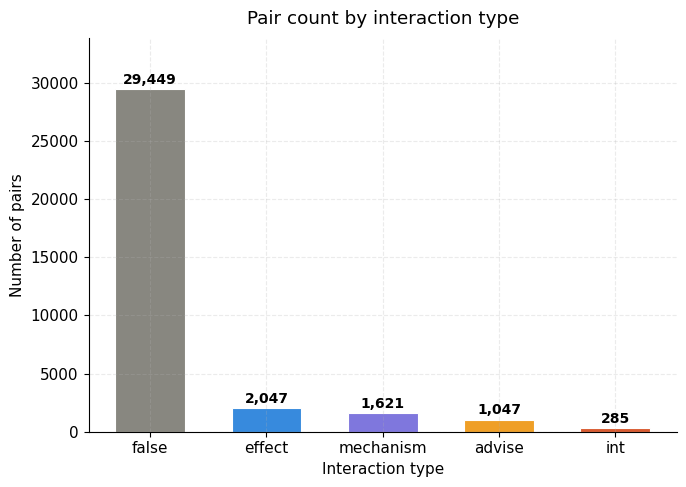

In [3]:
# Interaction Type Distribution (Raw Counts)

plt.figure(figsize=(7, 5))

counts = df['interaction_type'].value_counts().reindex(LABEL_ORDER)
colours = [LABEL_COLOURS[l] for l in LABEL_ORDER]

bars = plt.bar(
    counts.index, counts.values,
    color=colours, width=0.6,
    edgecolor='white', linewidth=0.8
)

for bar, val in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 180,
        f'{val:,}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

plt.title('Pair count by interaction type', pad=10)
plt.xlabel('Interaction type')
plt.ylabel('Number of pairs')
plt.ylim(0, counts.max() * 1.15)

plt.tight_layout()
save_fig('class_distribution_raw')

## Interaction Type Distribution (Log Scale)

This section visualises the interaction type distribution on a logarithmic scale to better highlight differences among minority classes. While the raw count plot is dominated by the majority class, the log scale makes smaller classes such as `mechanism`, `effect`, `advise`, and `int` more distinguishable.

This view provides a clearer understanding of class imbalance across all categories and helps assess how severely minority classes are underrepresented. The imbalance ratio between negative (`false`) and interaction classes is also computed, reinforcing the need for appropriate evaluation metrics such as Macro F1 and techniques like class weighting during model training.

Imbalance ratio (false / int): 103.3×


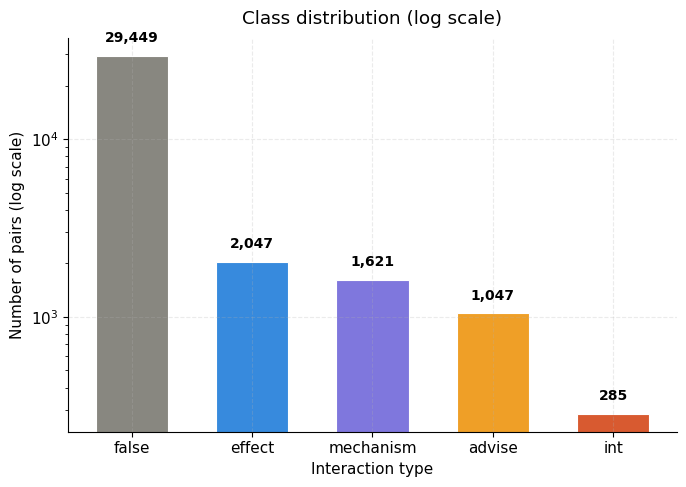

In [4]:
# Interaction Type Distribution (Log Scale)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    counts.index, counts.values,
    color=colours, width=0.6,
    edgecolor='white', linewidth=0.8
)

plt.yscale('log')

for bar, val in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.15,
        f'{val:,}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

plt.title('Class distribution (log scale)', pad=10)
plt.xlabel('Interaction type')
plt.ylabel('Number of pairs (log scale)')

plt.tight_layout()
save_fig('class_distribution_log')

# Summary
ratio = counts['false'] / counts['int']
print(f'Imbalance ratio (false / int): {ratio:.1f}×')

## Sentence Length Distribution by Interaction Type

This section analyses how sentence length varies across different interaction types using density curves. Each curve represents the distribution of word counts for a specific class, allowing comparison of linguistic patterns across interaction categories.

The plot helps identify whether certain interaction types tend to appear in longer or shorter sentences. While the differences are not extremely pronounced, subtle variations can still provide useful signals. The summary statistics further quantify these patterns by reporting the mean sentence length per class and identifying extreme cases such as very long sentences.

Overall, sentence length is not a strong standalone predictor but serves as a lightweight and interpretable feature that can complement other textual and semantic features in later modelling stages.

Mean sentence length per class:
false        36.0 words
effect       25.5 words
mechanism    29.1 words
advise       27.0 words
int          35.9 words

Sentences > 100 words: 0 rows


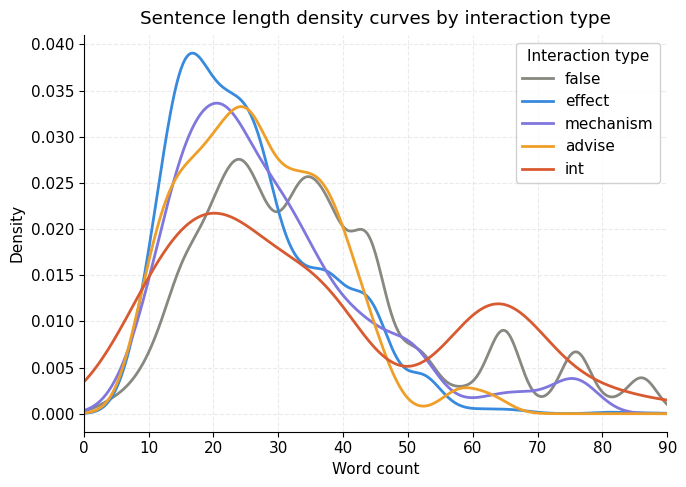

In [5]:
# Sentence Length — Density Curves

plt.figure(figsize=(7, 5))

for label in LABEL_ORDER:
    subset = df[df['interaction_type'] == label]['sentence_length']
    subset.plot.kde(
        label=label,
        color=LABEL_COLOURS[label],
        linewidth=2
    )

plt.xlim(0, 90)
plt.title('Sentence length density curves by interaction type', pad=8)
plt.xlabel('Word count')
plt.ylabel('Density')
plt.legend(title='Interaction type', framealpha=0.9)

plt.tight_layout()
save_fig('sentence_length_density')


# Summary Statistics
print('Mean sentence length per class:')
means = df.groupby('interaction_type')['sentence_length'].mean().reindex(LABEL_ORDER).round(1)

for label, mean in means.items():
    print(f'{label:<12} {mean} words')

print(f'\nSentences > 100 words: {(df["sentence_length"] > 100).sum()} rows')

## Drug Frequency Analysis

This section examines the frequency of drug mentions across the dataset, both overall and specifically within positive interaction cases (`ddi=True`). By aggregating drug names from both entities in each pair, the analysis highlights which drugs appear most frequently in the corpus.

The comparison between overall mentions and interaction-specific mentions helps identify drugs that are not only common but also more likely to participate in interactions. This distinction is useful for understanding dataset bias and for interpreting model predictions, as frequently occurring drugs may dominate learning patterns.

Overall, this analysis provides insight into entity distribution and interaction density, which is important for feature engineering and for diagnosing potential skew in model behaviour.

Total unique drug names in corpus : 2,731
Total unique drugs in interactions: 1,774

Top 5 overall: ['phenytoin', 'warfarin', 'digoxin', 'theophylline', 'ketoconazole']
Top 5 in interactions: ['phenytoin', 'ketoconazole', 'warfarin', 'anticoagulant', 'tricyclic antidepressants']


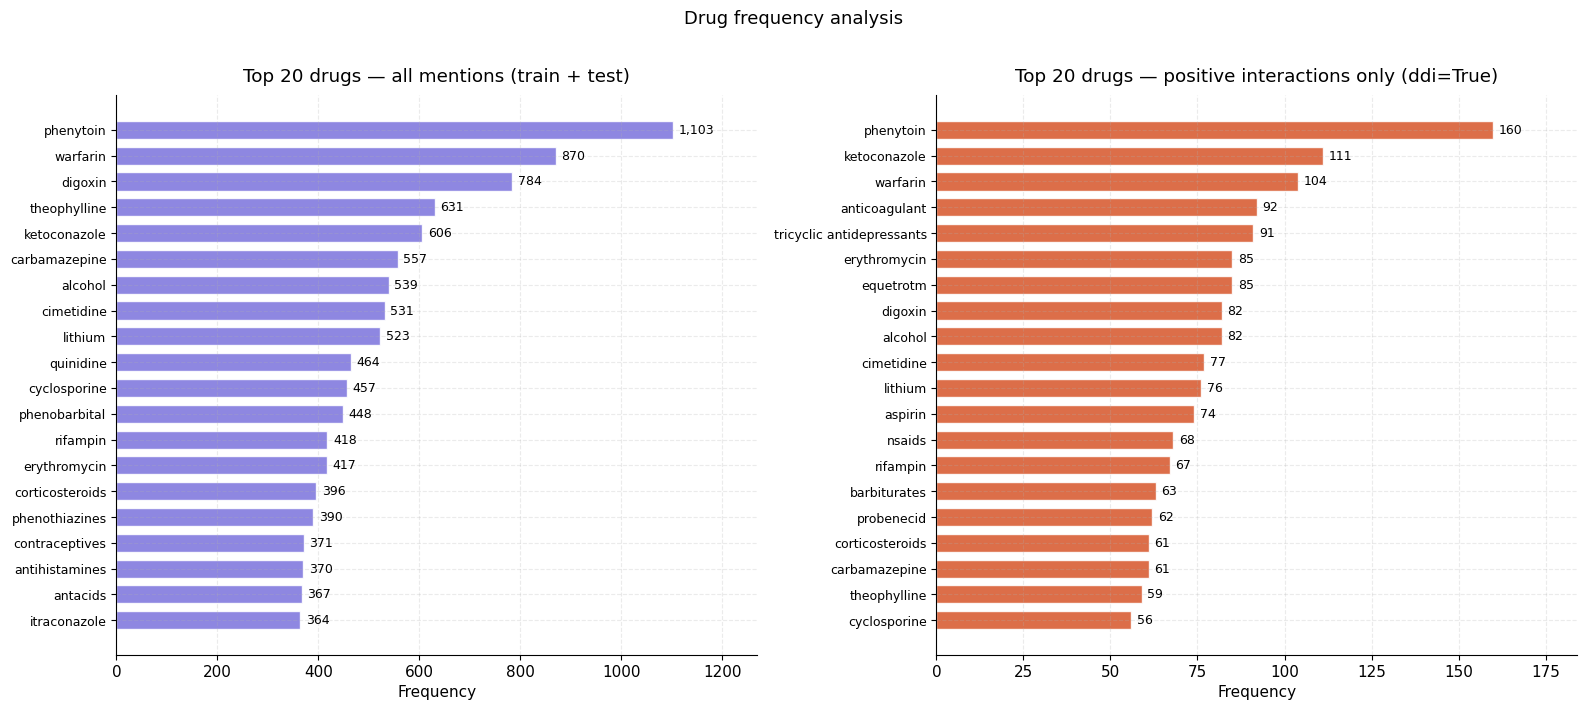

In [6]:
# Aggregate Drug Mentions
all_drugs = pd.concat([df['drug1_text'], df['drug2_text']]).str.lower().str.strip()
drug_freq = all_drugs.value_counts()

# Positive Interaction Drugs
pos_df = df[df['ddi'] == True]
pos_drugs = pd.concat([pos_df['drug1_text'], pos_df['drug2_text']]).str.lower().str.strip()
pos_freq = pos_drugs.value_counts()


# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, freq, title, colour in zip(
    axes,
    [drug_freq.head(20), pos_freq.head(20)],
    ['Top 20 drugs — all mentions (train + test)',
     'Top 20 drugs — positive interactions only (ddi=True)'],
    ['#7F77DD', '#D85A30']
):
    ax.barh(
        freq.index[::-1], freq.values[::-1],
        color=colour, edgecolor='white',
        alpha=0.88, height=0.7
    )

    for i, (name, val) in enumerate(zip(freq.index[::-1], freq.values[::-1])):
        ax.text(
            val + freq.values.max() * 0.01, i,
            f'{val:,}', va='center', fontsize=9
        )

    ax.set_title(title, pad=10)
    ax.set_xlabel('Frequency')
    ax.margins(x=0.15)
    ax.yaxis.set_tick_params(labelsize=9)


# Layout
plt.suptitle('Drug frequency analysis', fontsize=13, y=1.01)
plt.tight_layout()

save_fig('drug_frequency')


# Summary Statistics
print(f'Total unique drug names in corpus : {drug_freq.shape[0]:,}')
print(f'Total unique drugs in interactions: {pos_freq.shape[0]:,}')

print(f'\nTop 5 overall: {list(drug_freq.head(5).index)}')
print(f'Top 5 in interactions: {list(pos_freq.head(5).index)}')

## Interaction Type Breakdown for Top Drugs

This section analyses how interaction types are distributed for the most frequently occurring drugs in the dataset. Instead of looking at absolute counts, the distribution is normalised into percentages, allowing a fair comparison across drugs with different frequencies.

Each stacked bar represents a drug, showing the proportion of interaction types (`mechanism`, `effect`, `advise`, `int`, `false`) among all its occurrences. This helps identify whether certain drugs are more associated with specific types of interactions or are predominantly involved in non-interaction (`false`) pairs.

Such patterns are useful for understanding dataset bias at the entity level and can influence model behaviour, especially if certain drugs are strongly correlated with specific labels. This insight is valuable when interpreting predictions and designing more robust models.

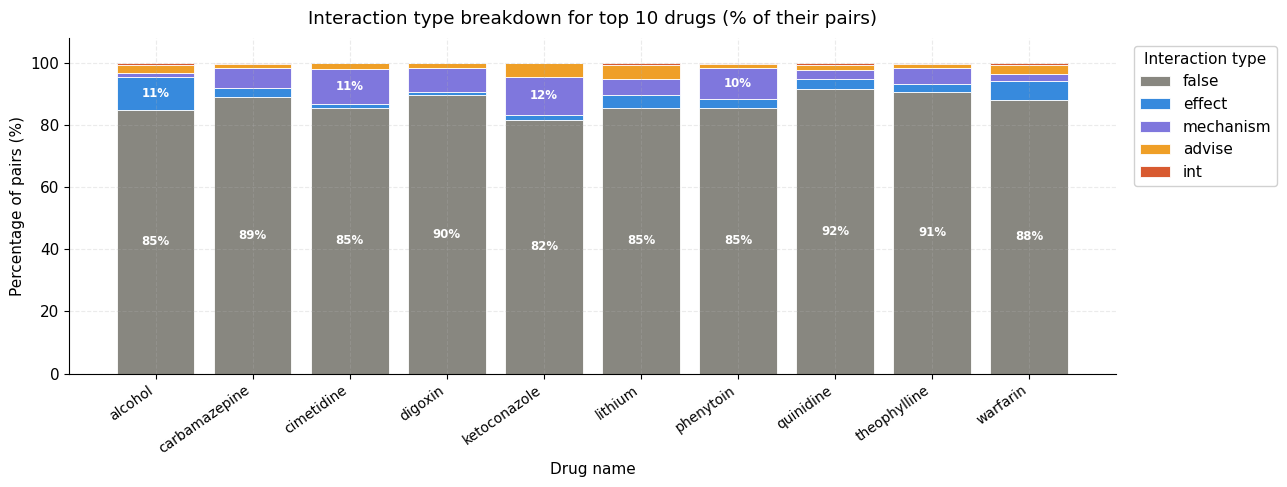

In [7]:
# Top 10 Drugs
top10_drugs = drug_freq.head(10).index.tolist()

# Combine Drug Mentions
stacked = pd.concat([
    df[['drug1_text', 'interaction_type']].rename(columns={'drug1_text': 'drug'}),
    df[['drug2_text', 'interaction_type']].rename(columns={'drug2_text': 'drug'}),
])

# Normalisation
stacked['drug'] = stacked['drug'].str.lower().str.strip()
stacked = stacked[stacked['drug'].isin(top10_drugs)]

# Compute Distribution
pivot = stacked.groupby(['drug', 'interaction_type']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=LABEL_ORDER, fill_value=0)

# Convert to Percentage
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100


# Plot
fig, ax = plt.subplots(figsize=(13, 5))

bottom = np.zeros(len(pivot_pct))

for label in LABEL_ORDER:
    vals = pivot_pct[label].values

    bars = ax.bar(
        pivot_pct.index, vals,
        bottom=bottom,
        label=label,
        color=LABEL_COLOURS[label],
        edgecolor='white',
        linewidth=0.6
    )

    # Annotate Larger Segments
    for bar, val in zip(bars, vals):
        if val > 8:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}%',
                ha='center', va='center',
                fontsize=8.5,
                color='white',
                fontweight='bold'
            )

    bottom += vals


# Formatting
ax.set_title('Interaction type breakdown for top 10 drugs (% of their pairs)', pad=10)
ax.set_xlabel('Drug name')
ax.set_ylabel('Percentage of pairs (%)')
ax.set_ylim(0, 108)

ax.legend(
    title='Interaction type',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    framealpha=0.9
)

plt.xticks(rotation=35, ha='right', fontsize=10)

plt.tight_layout()
save_fig('drug_interaction_breakdown')

## Interaction Rate by Entity Type Combination

This section analyses how interaction types vary across different combinations of entity types using a heatmap representation. Each row corresponds to a specific drug type pairing (e.g., drug–drug, drug–group), and each column represents an interaction category.

The values are normalised as percentages, allowing comparison of interaction tendencies across entity combinations regardless of their frequency. This helps reveal whether certain type combinations are more likely to result in specific interaction types or non-interactions.

Such patterns are useful for understanding structural biases in the dataset and can inform feature engineering, particularly when incorporating entity-type information into models.

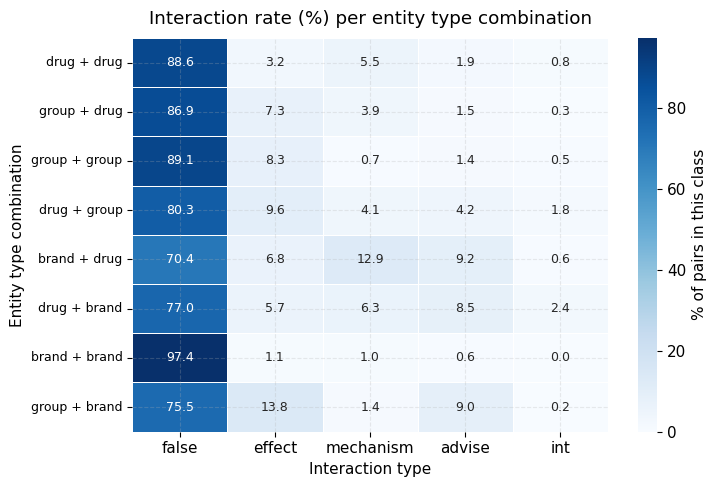

In [8]:
# Interaction Rate Heatmap

plt.figure(figsize=(7.5, 5))

top8 = df['type_combo'].value_counts().head(8).index

combo_label = pd.crosstab(df['type_combo'], df['interaction_type'])
combo_label = combo_label.reindex(index=top8, columns=LABEL_ORDER, fill_value=0)

# Convert to Percentage
combo_rate = combo_label.div(combo_label.sum(axis=1), axis=0) * 100

sns.heatmap(
    combo_rate,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': '% of pairs in this class'},
    annot_kws={'size': 9}
)

plt.title('Interaction rate (%) per entity type combination', pad=10)
plt.xlabel('Interaction type')
plt.ylabel('Entity type combination')

plt.gca().tick_params(axis='y', labelsize=9)

plt.tight_layout()
save_fig('entity_type_heatmap')

## Pairs per Sentence Distribution

This section analyses how many drug pairs are generated from each sentence in the dataset. Since multiple entities can appear in a single sentence, the number of possible pairs grows combinatorially, leading to variability in pair counts.

The histogram (capped at 30 pairs) provides a clearer view of the typical distribution while avoiding distortion from extreme outliers. The annotation highlights the maximum number of pairs observed in a single sentence, indicating the presence of dense entity-rich sentences.

This analysis confirms that multiple rows originating from the same sentence are expected and not duplicates. It also highlights potential bias where certain sentences contribute disproportionately more training examples, which is important to consider during model evaluation and splitting strategies.

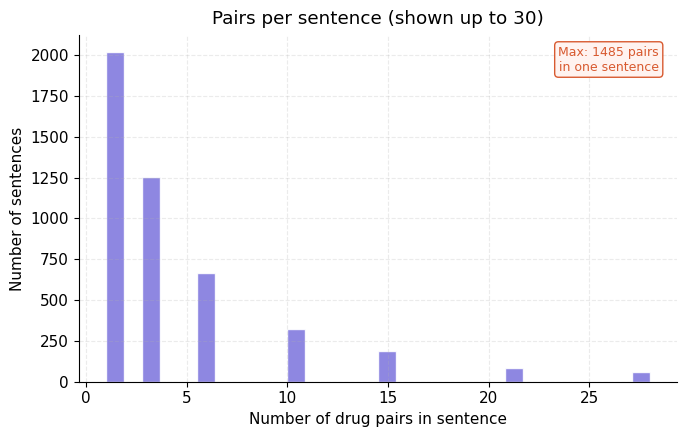

In [9]:
# Compute Pairs per Sentence
pairs_per = df.groupby('sentence_id').size().reset_index(name='pair_count')


# Histogram (Capped)
plt.figure(figsize=(7, 4.5))

cap = pairs_per[pairs_per['pair_count'] <= 30]['pair_count']

plt.hist(
    cap,
    bins=30,
    color='#7F77DD',
    edgecolor='white',
    alpha=0.88
)

plt.title('Pairs per sentence (shown up to 30)', pad=8)
plt.xlabel('Number of drug pairs in sentence')
plt.ylabel('Number of sentences')

plt.text(
    0.97, 0.97,
    f'Max: {pairs_per["pair_count"].max()} pairs\nin one sentence',
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=9, color='#D85A30',
    bbox=dict(boxstyle='round,pad=0.3',
              facecolor='#FFF3F0',
              edgecolor='#D85A30')
)

plt.tight_layout()
save_fig('pairs_per_sentence_hist')

## Cumulative Distribution of Pairs per Sentence

This section presents the cumulative distribution function (CDF) of the number of drug pairs per sentence. Unlike the histogram, this view shows the proportion of sentences that contain up to a given number of pairs, providing a clearer understanding of how pair counts accumulate across the dataset.

The vertical reference line at 10 pairs highlights how many sentences fall below this threshold, indicating that most sentences contain relatively few drug pairs, while only a small fraction contribute a large number of pairs. This confirms that the dataset is skewed, with a minority of sentences generating disproportionately many examples.

Such behaviour is important for modelling, as it may introduce bias where certain sentences dominate training. It also supports the need for careful evaluation strategies, ensuring that sentence-level leakage or over-representation is avoided.

Sentences with 1 pair : 2,021 (42.6%)
Sentences with 2–5 pairs : 1,253
Sentences with >10 pairs : 486 (10.2%)
Max pairs in one sentence: 1485


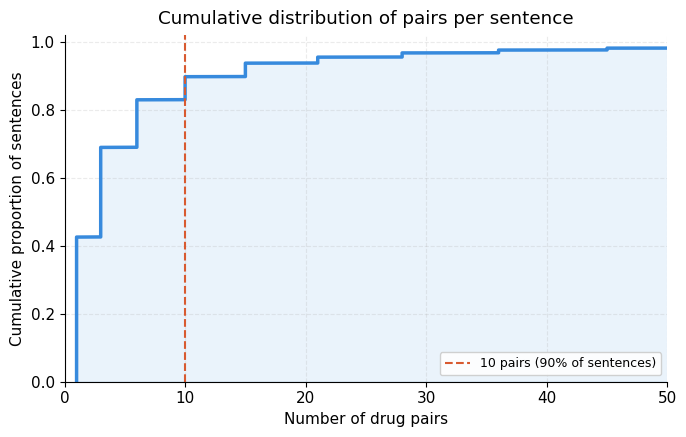

In [10]:
# Cumulative Distribution

plt.figure(figsize=(7, 4.5))

sorted_counts = np.sort(pairs_per['pair_count'].values)
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)

plt.plot(
    sorted_counts,
    cdf,
    color='#378ADD',
    linewidth=2.5
)

plt.fill_between(
    sorted_counts,
    cdf,
    alpha=0.1,
    color='#378ADD'
)

plt.axvline(
    x=10,
    color='#D85A30',
    linestyle='--',
    linewidth=1.5,
    label=f'10 pairs ({(pairs_per["pair_count"] <= 10).mean()*100:.0f}% of sentences)'
)

plt.xlim(0, 50)
plt.ylim(0, 1.02)

plt.title('Cumulative distribution of pairs per sentence', pad=8)
plt.xlabel('Number of drug pairs')
plt.ylabel('Cumulative proportion of sentences')

plt.legend(fontsize=9, framealpha=0.9)

plt.tight_layout()
save_fig('pairs_per_sentence_cdf')


# Summary Statistics
one_pair = (pairs_per['pair_count'] == 1).sum()
many_pairs = (pairs_per['pair_count'] > 10).sum()

print(f'Sentences with 1 pair : {one_pair:,} ({one_pair/len(pairs_per)*100:.1f}%)')
print(f'Sentences with 2–5 pairs : {((pairs_per["pair_count"] >= 2) & (pairs_per["pair_count"] <= 5)).sum():,}')
print(f'Sentences with >10 pairs : {many_pairs:,} ({many_pairs/len(pairs_per)*100:.1f}%)')
print(f'Max pairs in one sentence: {pairs_per["pair_count"].max()}')

## Keyword–Class Association Analysis

This section analyses how predefined domain-specific keywords are distributed across interaction types to assess their discriminative power. Keywords are grouped into semantic categories such as `mechanism`, `effect`, `advise`, and `general`, and their occurrence is measured as a percentage within each class.

The heatmap provides a class-normalised view, allowing direct comparison of how strongly each keyword is associated with different interaction types. Higher percentages indicate that a keyword is more characteristic of that class, suggesting its usefulness as an interpretable signal.

Additionally, the most discriminative keyword from each group is identified based on its highest occurrence within the expected class. This helps validate whether manually defined lexical cues align with the dataset labels and supports their inclusion as engineered features in downstream modelling.

Most discriminative keyword per group (highest rate in expected class):
mechanism    best keyword: "inhibit"  (25.4% of mechanism sentences)
effect       best keyword: "toxicity"  (5.0% of effect sentences)
advise       best keyword: "caution"  (23.5% of advise sentences)
general      best keyword: "increase"  (19.8% of effect sentences)


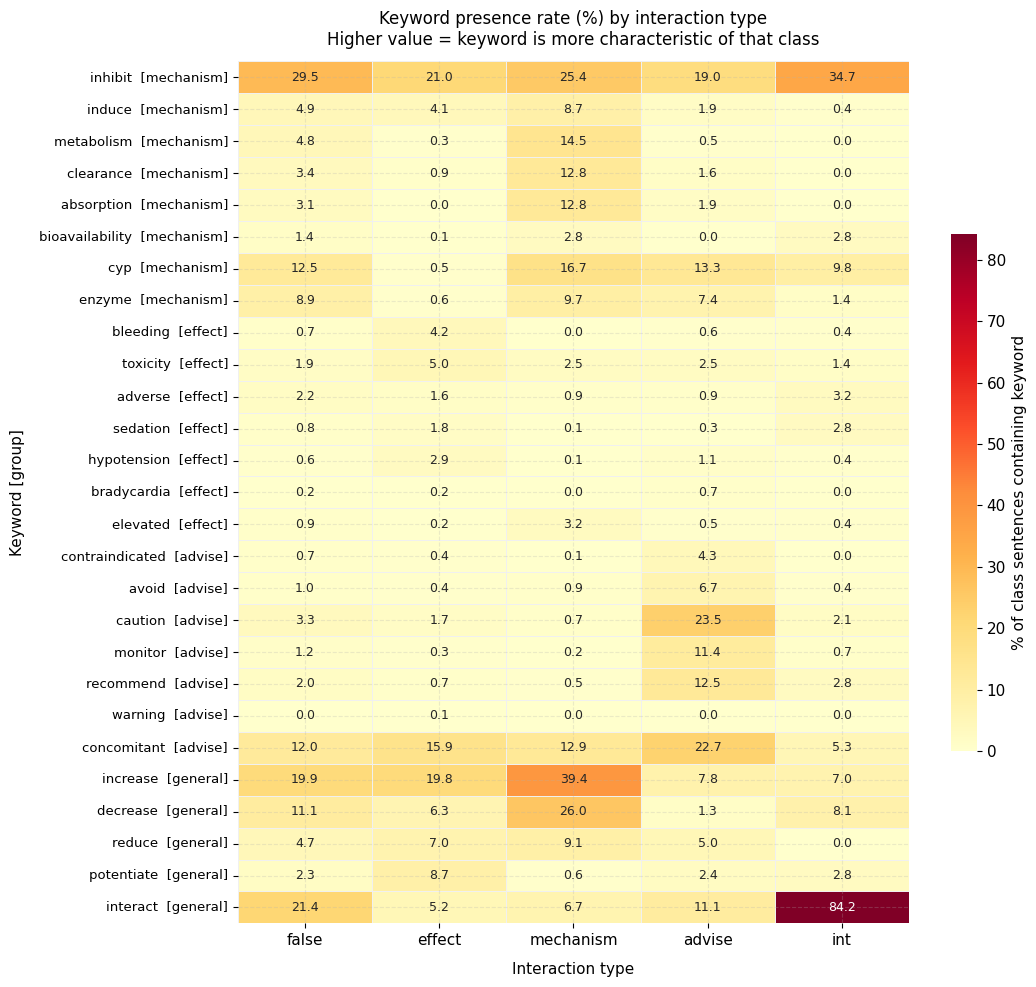

In [22]:
# Keyword Definitions
KEYWORDS = {
    'mechanism': ['inhibit', 'induce', 'metabolism', 'clearance', 'absorption',
                  'bioavailability', 'cyp', 'enzyme'],
    'effect': ['bleeding', 'toxicity', 'adverse', 'sedation',
                  'hypotension', 'bradycardia', 'elevated'],
    'advise': ['contraindicated', 'avoid', 'caution', 'monitor',
                  'recommend', 'warning', 'concomitant'],
    'general': ['increase', 'decrease', 'reduce', 'potentiate', 'interact'],
}

# Group to Label Mapping
GROUP_TO_LABEL = {
    'mechanism': 'mechanism',
    'effect': 'effect',
    'advise': 'advise',
    'general': 'effect',
}


# Compute Keyword Counts
all_kws = [kw for group in KEYWORDS.values() for kw in group]

results = {}
for kw in all_kws:
    row = {}
    for label in LABEL_ORDER:
        subset = df[df['interaction_type'] == label]['sentence_text'].str.lower()
        row[label] = subset.str.contains(kw, regex=False).sum()
    results[kw] = row

kw_df = pd.DataFrame(results).T.reindex(columns=LABEL_ORDER)


# Normalise to Percentage
class_n = df['interaction_type'].value_counts().reindex(LABEL_ORDER)
kw_rate = kw_df.div(class_n) * 100


# Annotate with Group Labels
group_labels = {kw: grp for grp, kws in KEYWORDS.items() for kw in kws}
kw_rate.index = [f'{kw}  [{group_labels[kw]}]' for kw in kw_rate.index]


# Heatmap Visualization
plt.figure(figsize=(11, 10))

sns.heatmap(
    kw_rate,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='#f0f0f0',
    cbar_kws={'label': '% of class sentences containing keyword', 'shrink': 0.6},
    annot_kws={'size': 9}
)

plt.title(
    'Keyword presence rate (%) by interaction type\n'
    'Higher value = keyword is more characteristic of that class',
    fontsize=12, pad=12
)

plt.xlabel('Interaction type', labelpad=10)
plt.ylabel('Keyword [group]', labelpad=10)

plt.gca().tick_params(axis='y', labelsize=9.5)

plt.tight_layout()
save_fig('keyword_heatmap')


# Most Discriminative Keywords
print('Most discriminative keyword per group (highest rate in expected class):')

for grp, kws in KEYWORDS.items():
    target_col = GROUP_TO_LABEL[grp]

    best_kw = None
    best_rate = -1

    for kw in kws:
        matching = [r for r in kw_rate.index if r.startswith(kw + '  ')]
        if matching:
            rate = kw_rate.loc[matching[0], target_col]
            if rate > best_rate:
                best_rate = rate
                best_kw = kw

    if best_kw:
        print(f'{grp:<12} best keyword: "{best_kw}"  ({best_rate:.1f}% of {target_col} sentences)')
    else:
        print(f'{grp:<12} : no match found')

## Corpus-wise Interaction Distribution (DrugBank)

This section analyses the distribution of interaction types within the DrugBank subset of the dataset. By focusing on a single corpus source, it becomes easier to understand how label distributions vary across different data origins.

The plot presents the percentage of each interaction type, along with absolute counts, providing both relative and absolute perspectives. The overall interaction rate (`ddi=True`) is also highlighted, indicating how frequently true interactions occur within this corpus.

This analysis helps identify whether certain corpora are biased toward specific interaction types or contain higher proportions of positive interactions, which is important when interpreting model performance and generalisation across datasets.

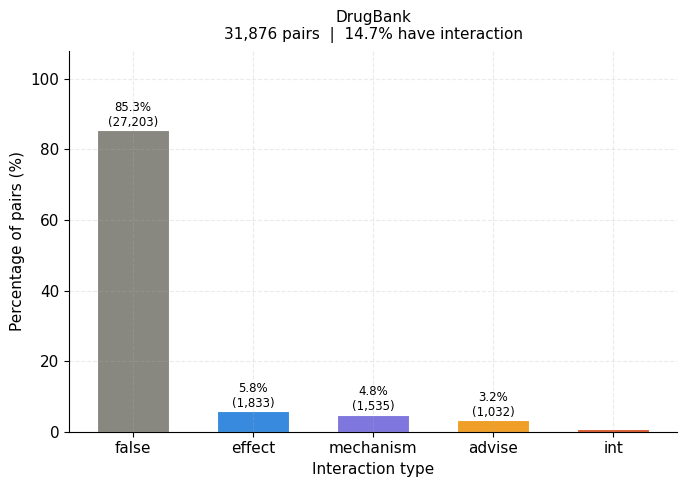

In [12]:
# Corpus-wise Distribution

plt.figure(figsize=(7, 5))

source = 'DrugBank'
sub = df[df['corpus_source'] == source]

counts = sub['interaction_type'].value_counts().reindex(LABEL_ORDER)
pcts = counts / counts.sum() * 100
int_rate = sub['ddi'].mean() * 100

bars = plt.bar(
    counts.index, pcts.values,
    color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

for bar, pct, cnt in zip(bars, pcts.values, counts.values):
    if pct > 1.5:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{pct:.1f}%\n({cnt:,})',
            ha='center', va='bottom',
            fontsize=8.5
        )

plt.title(
    f'{source}\n{len(sub):,} pairs  |  {int_rate:.1f}% have interaction',
    pad=8, fontsize=11
)

plt.xlabel('Interaction type')
plt.ylabel('Percentage of pairs (%)')
plt.ylim(0, 108)

plt.tight_layout()
save_fig('corpus_drugbank')

## Corpus-wise Interaction Distribution (MedLine)

This section presents the interaction type distribution for the MedLine subset, enabling comparison with the DrugBank corpus. The percentages reflect the proportion of each interaction type within MedLine, along with absolute counts for context.

Compared to DrugBank, MedLine typically exhibits a lower interaction rate and a higher proportion of negative (`false`) pairs. This indicates that MedLine data is less dense in explicit interactions and more representative of real-world clinical text, where interactions are less frequently stated.

The summary table consolidates key statistics across both corpora, highlighting differences in dataset composition, interaction density, and data volume. This comparison is important for understanding domain variability and for evaluating how well models generalise across different data sources.

  Source  Pairs  Interactions  Interaction rate %  Unique files
DrugBank  31876          4673                14.7           705
 MedLine   2573           327                12.7           180


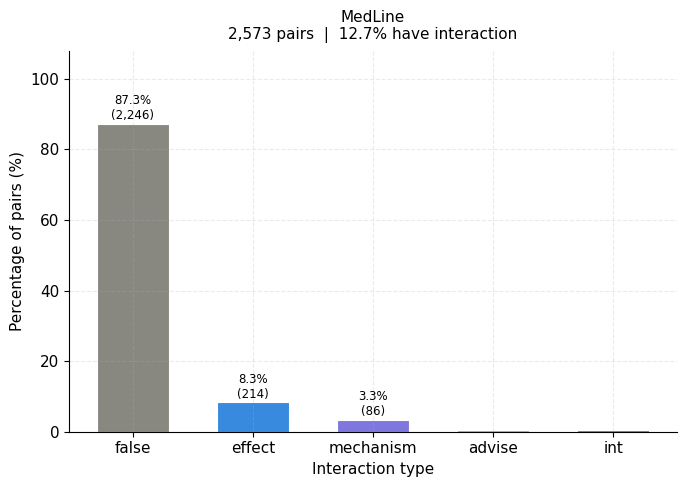

In [13]:
# MedLine Distribution

plt.figure(figsize=(7, 5))

source = 'MedLine'
sub = df[df['corpus_source'] == source]

counts = sub['interaction_type'].value_counts().reindex(LABEL_ORDER)
pcts = counts / counts.sum() * 100
int_rate = sub['ddi'].mean() * 100

bars = plt.bar(
    counts.index, pcts.values,
    color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

for bar, pct, cnt in zip(bars, pcts.values, counts.values):
    if pct > 1.5:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{pct:.1f}%\n({cnt:,})',
            ha='center', va='bottom',
            fontsize=8.5
        )

plt.title(
    f'{source}\n{len(sub):,} pairs  |  {int_rate:.1f}% have interaction',
    pad=8, fontsize=11
)

plt.xlabel('Interaction type')
plt.ylabel('Percentage of pairs (%)')
plt.ylim(0, 108)

plt.tight_layout()
save_fig('corpus_medline')


# Summary Table
source_stats = []

for source in ['DrugBank', 'MedLine']:
    sub = df[df['corpus_source'] == source]
    source_stats.append({
        'Source': source,
        'Pairs': len(sub),
        'Interactions': sub['ddi'].sum(),
        'Interaction rate %': round(sub['ddi'].mean() * 100, 1),
        'Unique files': sub['source_file'].nunique()
    })

stats_df = pd.DataFrame(source_stats)

print(stats_df.to_string(index=False))

## Negation Analysis by Interaction Type

This section investigates the presence of negation cues across different interaction types. Negation words such as “not”, “no”, and “without” are commonly used in biomedical text to indicate the absence of an interaction or to negate an effect.

The analysis computes the percentage of sentences within each class that contain at least one negation word. This helps identify whether negation is more prevalent in certain classes, particularly the `false` class, where interactions are explicitly denied.

Understanding negation patterns is important because they can significantly affect model predictions. Capturing negation correctly can improve classification performance, making it a valuable feature for both rule-based and machine learning approaches.

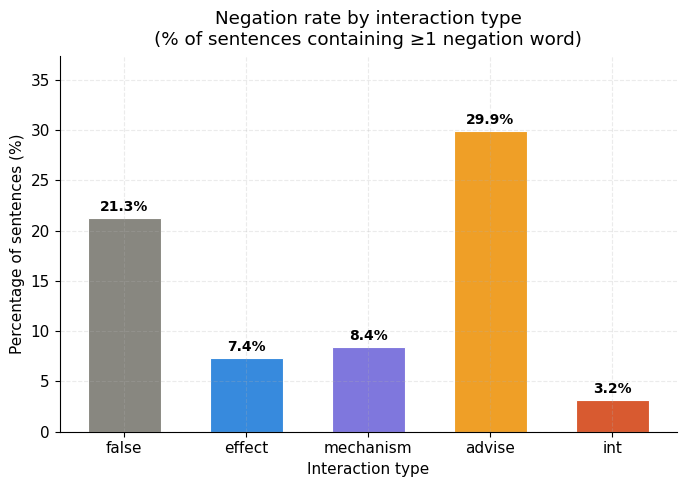

In [14]:
# Negation Words
NEGATION_WORDS = ['not', 'no', 'without', 'neither', 'nor', 'never', 'none']


# Compute Negation Rates per Class
neg_rates = {}
neg_word_counts = {}

for label in LABEL_ORDER:
    sub = df[df['interaction_type'] == label]['sentence_text'].str.lower()
    has_neg = sub.apply(lambda s: any(nw in str(s).split() for nw in NEGATION_WORDS)).sum()
    neg_rates[label] = has_neg / len(sub) * 100


# Count Individual Negation Words
for nw in NEGATION_WORDS:
    neg_word_counts[nw] = df['sentence_text'].str.lower().str.split().apply(
        lambda x: nw in x
    ).sum()


# Plot — Negation Rate per Class
plt.figure(figsize=(7, 5))

labels = list(neg_rates.keys())
rates = list(neg_rates.values())
colours = [LABEL_COLOURS[l] for l in labels]

bars = plt.bar(
    labels, rates,
    color=colours,
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{rate:.1f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

plt.title(
    'Negation rate by interaction type\n(% of sentences containing ≥1 negation word)',
    pad=8
)
plt.xlabel('Interaction type')
plt.ylabel('Percentage of sentences (%)')
plt.ylim(0, max(rates) * 1.25)

plt.tight_layout()
save_fig('negation_rate')

## Train–Test Overlap and Pair Density Analysis

This section verifies the integrity of the train–test split by checking for overlapping sentences between the two sets. Ensuring minimal or no overlap is important to prevent data leakage, which could artificially inflate model performance.

The analysis computes the number of unique sentences in each split and identifies any shared sentences. If overlap exists, its impact is quantified in terms of affected test rows. In practice, a very small overlap (e.g., <0.3%) is negligible and does not significantly bias evaluation metrics.

Additionally, the section examines how many sentences generate multiple drug pairs within each split. This behaviour is expected due to combinatorial pairing of entities within a sentence and should not be mistaken for duplication. However, it is important to be aware of this structure when designing evaluation strategies to avoid sentence-level leakage.

In [15]:
# Cross-Split Overlap Check
train_sents = set(train_df['sentence_text'].str.strip())
test_sents = set(test_df['sentence_text'].str.strip())

overlap = train_sents & test_sents

print(f'Unique sentences in train : {len(train_sents):,}')
print(f'Unique sentences in test : {len(test_sents):,}')
print(f'Sentences in BOTH splits : {len(overlap):,}')


# Overlap Impact Analysis
if len(overlap) > 0:
    overlap_rows = test_df[test_df['sentence_text'].str.strip().isin(overlap)]

    print(f'\nTest rows affected : {len(overlap_rows):,} ({len(overlap_rows)/len(test_df)*100:.2f}% of test set)')
    print('\nExample overlapping sentence:')
    print(' ', list(overlap)[0][:130])
    print()

    print('Note: <0.3% overlap is negligible — does not meaningfully inflate F1 scores.')
else:
    print('\nNo cross-split overlap. Train/test split is clean.')


# Within-Split Pair Density (Expected Behaviour)
pairs_per_sent = df.groupby(['split', 'sentence_text']).size().reset_index(name='pairs')

train_multi = (pairs_per_sent[pairs_per_sent['split'] == 'train']['pairs'] > 1).sum()
test_multi  = (pairs_per_sent[pairs_per_sent['split'] == 'test']['pairs'] > 1).sum()

print(f'\nSentences generating >1 pair (train): {train_multi:,} — expected, not a problem')
print(f'Sentences generating >1 pair (test) : {test_multi:,} — expected, not a problem')

Unique sentences in train : 3,706
Unique sentences in test : 951
Sentences in BOTH splits : 18

Test rows affected : 74 (1.11% of test set)

Example overlapping sentence:
  Drugs such as troleandomycin and ketoconazole may inhibit the metabolism of corticosteroids and thus decrease their clearance.

Note: <0.3% overlap is negligible — does not meaningfully inflate F1 scores.

Sentences generating >1 pair (train): 2,175 — expected, not a problem
Sentences generating >1 pair (test) : 530 — expected, not a problem


## Vocabulary Distribution and Zipf’s Law

This section analyses the vocabulary distribution of the dataset by tokenising all sentences and examining word frequency patterns. The tokenisation captures alphabetic tokens, including hyphenated terms, which are common in biomedical text.

The log–log plot visualises Zipf’s Law, where a small number of words occur very frequently while the majority appear rarely. This results in a long-tailed distribution, which is typical for natural language data.

The vertical markers indicate the chosen vocabulary cutoff (e.g., `max_features=5000`) and the total vocabulary size. This helps justify feature selection decisions in later stages, as limiting the vocabulary can reduce noise and computational cost while retaining the most informative terms.

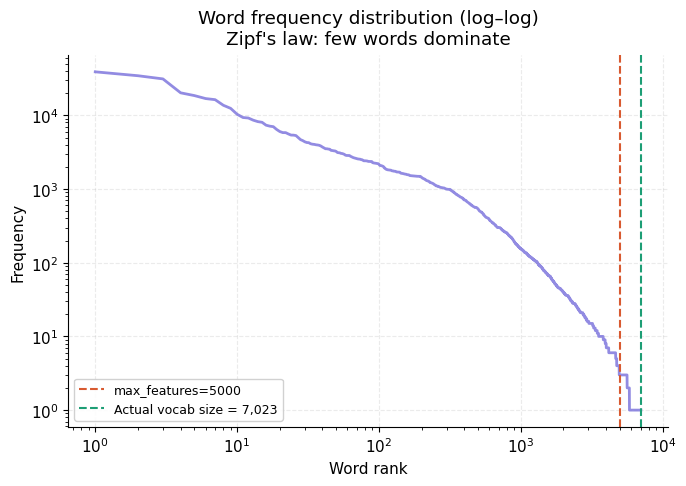

In [16]:
# Tokenisation and Vocabulary Construction
all_text = ' '.join(df['sentence_text'].str.lower().fillna('').tolist())
all_tokens = re.findall(r'\b[a-z][a-z\-]+\b', all_text)

vocab = Counter(all_tokens)


# Frequency Buckets
freq_once = sum(1 for c in vocab.values() if c == 1)
freq_rare = sum(1 for c in vocab.values() if 1 < c <= 5)
freq_mid  = sum(1 for c in vocab.values() if 5 < c <= 50)
freq_high = sum(1 for c in vocab.values() if c > 50)


# Plot — Zipf's Law
plt.figure(figsize=(7, 5))

sorted_freqs = sorted(vocab.values(), reverse=True)

plt.loglog(
    range(1, len(sorted_freqs) + 1),
    sorted_freqs,
    color='#7F77DD',
    linewidth=2,
    alpha=0.85
)

plt.axvline(
    x=5000,
    color='#D85A30',
    linestyle='--',
    linewidth=1.5,
    label='max_features=5000'
)

plt.axvline(
    x=len(vocab),
    color='#1D9E75',
    linestyle='--',
    linewidth=1.5,
    label=f'Actual vocab size = {len(vocab):,}'
)

plt.title("Word frequency distribution (log–log)\nZipf's law: few words dominate", pad=8)
plt.xlabel('Word rank')
plt.ylabel('Frequency')
plt.legend(fontsize=9, framealpha=0.9)

plt.tight_layout()
save_fig('vocab_zipf')

## Most Frequent Interacting Drug Pairs

This section identifies the most frequently occurring drug–drug interaction pairs in the dataset, focusing only on positive interaction cases (`ddi=True`). Each unique pair is normalised by sorting drug names to avoid duplication due to ordering.

The plot displays the top 20 most common interacting pairs, with bar colours indicating the dominant interaction type associated with each pair. A priority-based approach is used to assign a single representative interaction type when multiple labels exist for the same pair.

This analysis provides insight into recurring interaction patterns and highlights high-frequency drug combinations that may strongly influence model learning. It also helps in interpreting model outputs, as frequently observed pairs are more likely to be learned effectively.

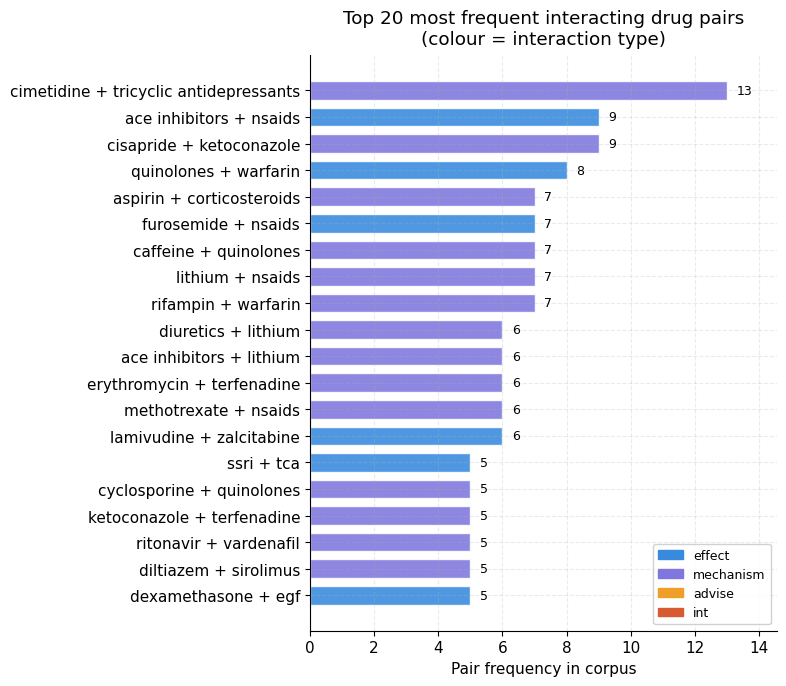

In [17]:
pos_df = df[df['ddi'] == True].copy()

pair_type  = {}
pair_count = Counter()

for _, row in pos_df.iterrows():
    d1 = str(row['drug1_text']).lower().strip()
    d2 = str(row['drug2_text']).lower().strip()
    pair = tuple(sorted([d1, d2]))

    pair_count[pair] += 1

    existing = pair_type.get(pair, 'int')
    priority = {'mechanism': 0, 'effect': 1, 'advise': 2, 'int': 3}

    if priority.get(row['interaction_type'], 3) < priority.get(existing, 3):
        pair_type[pair] = row['interaction_type']


top_pairs = pair_count.most_common(20)


# Plot — Top Interacting Pairs
plt.figure(figsize=(8, 7))

pair_labels  = [f'{p[0][0]} + {p[0][1]}' for p in top_pairs]
pair_vals    = [p[1] for p in top_pairs]
pair_colours = [LABEL_COLOURS.get(pair_type.get(p[0], 'int'), '#888780') for p in top_pairs]

plt.barh(
    pair_labels[::-1],
    pair_vals[::-1],
    color=pair_colours[::-1],
    edgecolor='white',
    alpha=0.88,
    height=0.7
)

for i, val in enumerate(pair_vals[::-1]):
    plt.text(val + 0.3, i, str(val), va='center', fontsize=9)

plt.title('Top 20 most frequent interacting drug pairs\n(colour = interaction type)', pad=8)
plt.xlabel('Pair frequency in corpus')
plt.margins(x=0.12)

patches = [mpatches.Patch(color=LABEL_COLOURS[l], label=l) for l in LABEL_ORDER[1:]]
plt.legend(handles=patches, fontsize=9, loc='lower right', framealpha=0.9)

plt.tight_layout()
save_fig('13_top_pairs')

## Drug Interaction Network Analysis

This section visualises the relationships between drugs as a network, where each node represents a drug and each edge represents an interaction between two drugs. The network is constructed using the most frequent interacting pairs, allowing a focused view of the most relevant relationships in the dataset.

Edge thickness reflects the frequency of the interaction, while edge colour indicates the dominant interaction type. This provides an intuitive way to observe both the strength and nature of relationships between drugs.

The network highlights highly connected drugs that appear in multiple interactions, as well as frequently recurring pairs. Such patterns are useful for understanding interaction clusters and can inform downstream tasks such as recommendation systems or clinical decision support.

The summary statistics further quantify the diversity of interactions, including the number of unique pairs, sparsity of occurrences, and the most frequent interactions, which are good candidates for demonstration in later project stages.

Network graph drawn using networkx.
Unique interacting pairs : 4,046
Pairs appearing once : 3,396
Most frequent pair : cimetidine + tricyclic antidepressants (13×)

Suggested pairs for Phase 6 demo:
cimetidine + tricyclic antidepressants — mechanism (13×)
ace inhibitors + nsaids — effect (9×)
cisapride + ketoconazole — mechanism (9×)
quinolones + warfarin — effect (8×)
aspirin + corticosteroids — mechanism (7×)


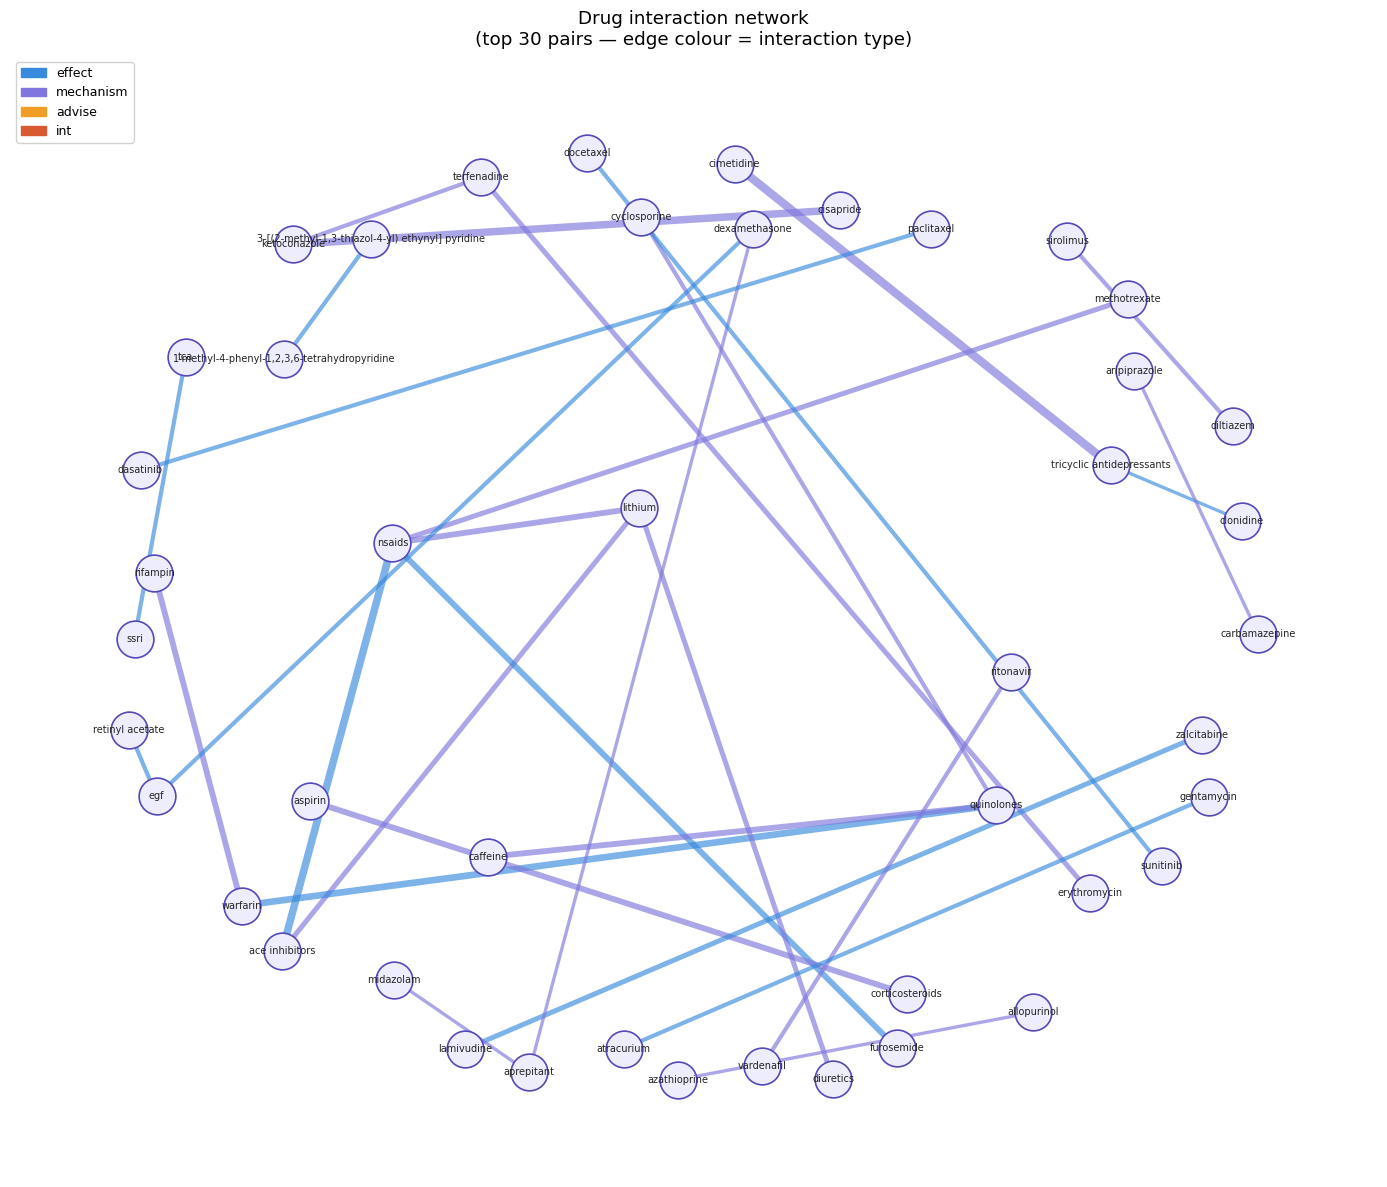

In [18]:
# Plot — Interaction Network

plt.figure(figsize=(14, 12))

try:
    import networkx as nx

    G = nx.Graph()

    for (d1, d2), count in pair_count.most_common(30):
        G.add_edge(
            d1, d2,
            weight=count,
            label=pair_type.get(tuple(sorted([d1, d2])), 'int')
        )

    pos = nx.spring_layout(G, seed=42, k=2.8)

    ecols = [LABEL_COLOURS.get(G[u][v]['label'], '#888780') for u, v in G.edges()]
    ewidths = [min(G[u][v]['weight'] * 0.6, 6) for u, v in G.edges()]

    nx.draw_networkx_nodes(
        G, pos,
        node_color='#EEEDFE',
        node_size=700,
        edgecolors='#534AB7',
        linewidths=1.2
    )

    nx.draw_networkx_labels(G, pos, font_size=7, font_color='#222')

    nx.draw_networkx_edges(
        G, pos,
        edge_color=ecols,
        width=ewidths,
        alpha=0.65
    )

    patches2 = [mpatches.Patch(color=LABEL_COLOURS[l], label=l) for l in LABEL_ORDER[1:]]
    plt.legend(handles=patches2, fontsize=9, loc='upper left', framealpha=0.9)

    plt.title('Drug interaction network\n(top 30 pairs — edge colour = interaction type)', pad=8)
    plt.axis('off')

    print('Network graph drawn using networkx.')

except ImportError:
    plt.text(
        0.5, 0.5,
        'Install networkx:\npip install networkx',
        ha='center', va='center',
        transform=plt.gca().transAxes,
        fontsize=11
    )
    plt.axis('off')
    print('networkx not installed. Run: pip install networkx')

plt.tight_layout()
save_fig('interaction_network')


# Summary Statistics
print(f'Unique interacting pairs : {len(pair_count):,}')
print(f'Pairs appearing once : {sum(1 for c in pair_count.values() if c==1):,}')
print(f'Most frequent pair : {top_pairs[0][0][0]} + {top_pairs[0][0][1]} ({top_pairs[0][1]}×)')

print('\nSuggested pairs for Phase 6 demo:')
for (d1, d2), cnt in top_pairs[:5]:
    itype = pair_type.get((d1, d2), 'int')
    print(f'{d1} + {d2} — {itype} ({cnt}×)')

## Drug Distance Feature Computation

This section computes the positional distance between the two drugs mentioned in each sentence. The distance is defined as the absolute difference in word indices between the first occurrence of each drug in the tokenised sentence.

This feature captures how far apart the interacting entities are within the sentence, which can provide useful contextual information. In many cases, shorter distances may indicate stronger or more direct relationships, while larger distances may correspond to more complex or loosely connected interactions.

Although this is a simple heuristic, it serves as an interpretable and computationally inexpensive feature that can be incorporated into classical models or used alongside learned representations in later stages.

In [19]:
def get_drug_distance(row):
    words = str(row['sentence_text']).lower().split()
    d1 = str(row['drug1_text']).lower()
    d2 = str(row['drug2_text']).lower()

    pos1 = next((i for i, w in enumerate(words) if d1 in w), None)
    pos2 = next((i for i, w in enumerate(words) if d2 in w), None)

    return abs(pos1 - pos2) if pos1 is not None and pos2 is not None else None


print('Computing drug distances')
df['drug_distance'] = df.apply(get_drug_distance, axis=1)

Computing drug distances


## Final Dataset Summary for Reporting

This section consolidates key dataset statistics into structured summary tables for reporting and analysis. The class-level summary captures the distribution of interaction types across train, test, and combined datasets, along with their relative proportions, average sentence lengths, and negation rates.

These metrics provide a comprehensive view of class imbalance, linguistic characteristics, and potential modelling challenges. In particular, the inclusion of negation rates and sentence length helps justify feature engineering choices made in later stages.

The source-level summary complements this by aggregating statistics at the corpus level, including total pairs, number of interactions, interaction rates, and average sentence lengths. This enables direct comparison between sources such as DrugBank and MedLine, highlighting differences in data density and complexity.

Both tables are saved as CSV files for seamless integration into reports and further analysis.

In [20]:
# Aggregate statistics for report

counts_train = train_df['interaction_type'].value_counts().reindex(LABEL_ORDER)
counts_test  = test_df['interaction_type'].value_counts().reindex(LABEL_ORDER)
counts_total = df['interaction_type'].value_counts().reindex(LABEL_ORDER)

means_len = df.groupby('interaction_type')['sentence_length'].mean().reindex(LABEL_ORDER)


# Class-level summary table
summary_rows = []

for label in LABEL_ORDER:
    summary_rows.append({
        'interaction_type': label,
        'train_count': counts_train[label],
        'test_count': counts_test[label],
        'total_count': counts_total[label],
        'total_pct': round(counts_total[label] / len(df) * 100, 2),
        'mean_sentence_len': round(means_len[label], 1),
        'negation_rate_pct': round(neg_rates.get(label, 0), 2),
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = Path(EDA_CLASS_SUMMARY_CSV)
summary_df.to_csv(summary_path, index=False)

print(summary_df.to_string(index=False))
print()

# Source-level summary table
source_summary = df.groupby('corpus_source').agg(
    total_pairs     = ('sentence_id', 'count'),
    interactions    = ('ddi', 'sum'),
    unique_files    = ('source_file', 'nunique'),
    mean_sent_len   = ('sentence_length', 'mean'),
).reset_index()

source_summary['interaction_rate_pct'] = (
    source_summary['interactions'] / source_summary['total_pairs'] * 100
).round(1)

source_summary['mean_sent_len'] = source_summary['mean_sent_len'].round(1)

source_path = Path(EDA_SOURCE_SUMMARY_CSV)
source_summary.to_csv(source_path, index=False)

print(source_summary.to_string(index=False))

interaction_type  train_count  test_count  total_count  total_pct  mean_sentence_len  negation_rate_pct
           false        23771        5678        29449      85.49               36.0              21.27
          effect         1687         360         2047       5.94               25.5               7.38
       mechanism         1319         302         1621       4.71               29.1               8.39
          advise          826         221         1047       3.04               27.0              29.89
             int          189          96          285       0.83               35.9               3.16

corpus_source  total_pairs  interactions  unique_files  mean_sent_len  interaction_rate_pct
     DrugBank        31876          4673           705           35.3                  14.7
      MedLine         2573           327           180           28.5                  12.7


## Summary of Findings

The dataset exhibits significant class imbalance, with the `false` class dominating, reinforcing the need for metrics such as Macro F1 and techniques like class weighting. Sentence length shows minor variation across classes, indicating it is a weak but useful auxiliary feature.

Drug frequency analysis reveals a small number of drugs and drug pairs appearing frequently, which may bias model learning. Interaction patterns vary across entity types and corpora, with DrugBank containing a higher density of interactions compared to MedLine, which is more representative of real-world clinical text.

Keyword and negation analyses confirm that certain linguistic patterns are associated with specific interaction types, supporting their use as interpretable features. Additionally, sentence-level analysis shows that multiple pairs per sentence are common and expected, while cross-split overlap is negligible and does not impact evaluation.

Overall, the dataset is well-structured but presents typical NLP challenges such as imbalance, long-tail vocabulary, and uneven distribution, all of which inform the modelling strategy in the next phase.